In [1]:
# Cell 1: Import libraries

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)

DATA_PATH = Path("../data/diabetic_data.csv")  # Change this path if required
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

In [2]:
# Cell 2: Load the dataset

df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.tail())

Dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,MC,?,51,0,16,0,0,0,250.13,291,458,9,NaN,>8,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,MC,?,33,3,18,0,0,1,560,276,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,MC,?,53,0,9,1,0,0,38,590,296,13,NaN,NaN,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,MC,Surgery-General,45,2,21,0,0,1,996,285,998,9,NaN,NaN,No,No,No,No,No,No,Steady,No,No,Steady,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,?,?,13,3,3,0,0,0,530,530,787,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO


In [3]:
# Cell 3: Basic structure

print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

print("\nData types:")
display(df_raw.dtypes.value_counts())

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nDataset information:")
df_raw.info()

Rows: 101766
Columns: 50

Data types:


str      37
int64    13
Name: count, dtype: int64


Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count

In [4]:
# Cell 4: Replace question marks with missing values

# In this dataset, '?' is used in several columns to represent missing/unknown values.
df = df_raw.replace("?", np.nan).copy()

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2),
    "data_type": df.dtypes.astype(str)
}).sort_values("missing_count", ascending=False)

display(missing_summary[missing_summary["missing_count"] > 0])

missing_summary.to_csv(OUTPUT_DIR / "missing_values_summary.csv")

,missing_count,missing_percentage,data_type
weight,98569,96.86,str
max_glu_serum,96420,94.75,str
A1Cresult,84748,83.28,str
medical_specialty,49949,49.08,str
payer_code,40256,39.56,str
race,2273,2.23,str
diag_3,1423,1.40,str
diag_2,358,0.35,str
diag_1,21,0.02,str


,count,percentage
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


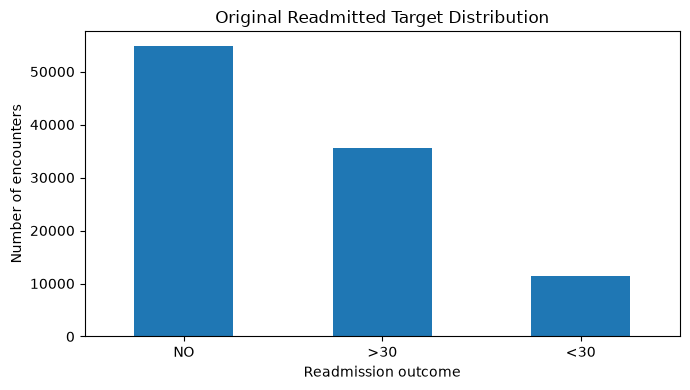

In [5]:
# Cell 5: Target variable distribution

target_counts = df["readmitted"].value_counts(dropna=False)
target_percentages = (df["readmitted"].value_counts(normalize=True, dropna=False) * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

display(target_summary)

ax = target_counts.reindex(["NO", ">30", "<30"]).plot(
    kind="bar",
    figsize=(7, 4),
    title="Original Readmitted Target Distribution"
)
ax.set_xlabel("Readmission outcome")
ax.set_ylabel("Number of encounters")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

target_summary.to_csv(OUTPUT_DIR / "target_distribution.csv")

In [6]:
# Cell 6: Confirm the three-class target

expected_classes = {"NO", ">30", "<30"}
actual_classes = set(df["readmitted"].dropna().unique())

print("Actual target classes:", actual_classes)
print("Expected classes:", expected_classes)
print("All expected classes present:", expected_classes.issubset(actual_classes))

Actual target classes: {'<30', '>30', 'NO'}
Expected classes: {'<30', '>30', 'NO'}
All expected classes present: True


In [7]:
# Cell 7: Identifier analysis

identifier_columns = ["encounter_id", "patient_nbr"]

identifier_summary = pd.DataFrame({
    "unique_values": [df[col].nunique(dropna=False) for col in identifier_columns],
    "duplicate_values": [df[col].duplicated().sum() for col in identifier_columns]
}, index=identifier_columns)

display(identifier_summary)

print("Exact duplicate rows:", df.duplicated().sum())
print("Unique patients:", df["patient_nbr"].nunique())
print("Patients with more than one encounter:",
      (df["patient_nbr"].value_counts() > 1).sum())

patient_encounter_counts = df["patient_nbr"].value_counts()
display(patient_encounter_counts.describe())

,unique_values,duplicate_values
encounter_id,101766,0
patient_nbr,71518,30248


Exact duplicate rows: 0
Unique patients: 71518
Patients with more than one encounter: 16773


count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
Name: count, dtype: float64

In [8]:
# Cell 8: Duplicate investigation

exact_duplicate_rows = df.duplicated().sum()
duplicate_encounter_ids = df["encounter_id"].duplicated().sum()

print("Exact duplicate rows:", exact_duplicate_rows)
print("Repeated encounter_id values:", duplicate_encounter_ids)

# Repeated patient_nbr values are not automatically duplicates.
# They may represent separate hospital encounters.
repeated_patient_records = df[df["patient_nbr"].duplicated(keep=False)].sort_values("patient_nbr")
display(repeated_patient_records[["patient_nbr", "encounter_id", "readmitted"]].head(20))

Exact duplicate rows: 0
Repeated encounter_id values: 0


,patient_nbr,encounter_id,readmitted
4780,135,26264286,>30
4267,135,24437208,<30
5953,1152,30180318,>30
23623,1152,80742510,>30
14180,1152,55533660,>30
24642,1152,83281464,NO
1164,1152,8380170,>30
19914,1314,70601076,NO
19765,1314,70190028,<30
15848,1314,60254142,>30


In [9]:
# Cell 9: Numerical feature summary

numeric_columns_raw = df.select_dtypes(include=["number"]).columns.tolist()

numeric_summary = df[numeric_columns_raw].describe().T
display(numeric_summary)

numeric_summary.to_csv(OUTPUT_DIR / "numeric_summary.csv")

,count,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,1.652016e+08,1.026403e+08,12522.0,84961194.0,152388987.0,2.302709e+08,443867222.0
patient_nbr,101766.0,5.433040e+07,3.869636e+07,135.0,23413221.0,45505143.0,8.754595e+07,189502619.0
admission_type_id,101766.0,2.024006e+00,1.445403e+00,1.0,1.0,1.0,3.000000e+00,8.0
discharge_disposition_id,101766.0,3.715642e+00,5.280166e+00,1.0,1.0,1.0,4.000000e+00,28.0
admission_source_id,101766.0,5.754437e+00,4.064081e+00,1.0,1.0,7.0,7.000000e+00,25.0
time_in_hospital,101766.0,4.395987e+00,2.985108e+00,1.0,2.0,4.0,6.000000e+00,14.0
num_lab_procedures,101766.0,4.309564e+01,1.967436e+01,1.0,31.0,44.0,5.700000e+01,132.0
num_procedures,101766.0,1.339730e+00,1.705807e+00,0.0,0.0,1.0,2.000000e+00,6.0
num_medications,101766.0,1.602184e+01,8.127566e+00,1.0,10.0,15.0,2.000000e+01,81.0
number_outpatient,101766.0,3.693572e-01,1.267265e+00,0.0,0.0,0.0,0.000000e+00,42.0


In [10]:
# Cell 10: Potential outlier investigation using IQR(Interquartile Range) method

# This reports possible statistical outliers; it does not delete them.
# Valid healthcare observations should not be removed automatically.

outlier_rows = []

for col in numeric_columns_raw:
    series = df[col].dropna()

    if series.nunique() <= 1:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    count = ((series < lower_bound) | (series > upper_bound)).sum()

    outlier_rows.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "possible_outlier_count": int(count),
        "possible_outlier_percentage": round(count / len(series) * 100, 2)
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values(
    "possible_outlier_count", ascending=False
)

display(outlier_summary)
outlier_summary.to_csv(OUTPUT_DIR / "iqr_outlier_summary.csv", index=False)

,column,Q1,Q3,IQR,lower_bound,upper_bound,possible_outlier_count,possible_outlier_percentage
9,number_outpatient,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,16739,16.45
10,number_emergency,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,11383,11.19
3,discharge_disposition_id,1.0,4.000000e+00,3.000000e+00,-3.500000e+00,8.500000e+00,9818,9.65
11,number_inpatient,0.0,1.000000e+00,1.000000e+00,-1.500000e+00,2.500000e+00,7049,6.93
4,admission_source_id,1.0,7.000000e+00,6.000000e+00,-8.000000e+00,1.600000e+01,6956,6.84
7,num_procedures,0.0,2.000000e+00,2.000000e+00,-3.000000e+00,5.000000e+00,4954,4.87
8,num_medications,10.0,2.000000e+01,1.000000e+01,-5.000000e+00,3.500000e+01,2557,2.51
5,time_in_hospital,2.0,6.000000e+00,4.000000e+00,-4.000000e+00,1.200000e+01,2252,2.21
2,admission_type_id,1.0,3.000000e+00,2.000000e+00,-2.000000e+00,6.000000e+00,341,0.34
12,number_diagnoses,6.0,9.000000e+00,3.000000e+00,1.500000e+00,1.350000e+01,281,0.28


In [11]:
# Cell 11: Check unusual categorical values

categorical_columns_raw = df.select_dtypes(include=["object"]).columns.tolist()

for col in ["gender", "race", "age", "admission_type_id",
            "discharge_disposition_id", "admission_source_id"]:
    if col in df.columns:
        print(f"\nColumn: {col}")
        display(df[col].value_counts(dropna=False).head(30))


Column: gender


gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


Column: race


race
Caucasian          76099
AfricanAmerican    19210
NaN                 2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


Column: age


...

admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64


Column: discharge_disposition_id


discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64


Column: admission_source_id


admission_source_id
7     57494
1     29565
17     6781
4      3187
6      2264
2      1104
5       855
3       187
20      161
9       125
8        16
22       12
10        8
14        2
11        2
25        2
13        1
Name: count, dtype: int64

In [12]:
# Cell 12: Class distribution by selected categorical variables

def class_percentage_table(column):
    table = pd.crosstab(
        df[column],
        df["readmitted"],
        normalize="index"
    ) * 100
    return table.round(2)

for col in ["age", "gender", "admission_type_id"]:
    if col in df.columns:
        print(f"\nReadmission distribution by {col}")
        display(class_percentage_table(col).head(30))


Readmission distribution by age


readmitted,<30,>30,NO
age,,,
[0-10),1.86,16.15,81.99
[10-20),5.79,32.42,61.79
[20-30),14.24,30.78,54.98
[30-40),11.23,31.44,57.32
[40-50),10.60,33.85,55.55
[50-60),9.67,34.29,56.04
[60-70),11.13,35.12,53.75
[70-80),11.77,36.35,51.88
[80-90),12.08,36.19,51.73



Readmission distribution by gender


readmitted,<30,>30,NO
gender,,,
Female,11.25,35.68,53.08
Male,11.06,34.06,54.88
Unknown/Invalid,0.00,0.00,100.00



Readmission distribution by admission_type_id


readmitted,<30,>30,NO
admission_type_id,,,
1,11.52,35.76,52.71
2,11.18,34.91,53.91
3,10.39,30.45,59.16
4,10.00,20.00,70.00
5,10.34,35.97,53.69
6,11.08,42.17,46.76
7,0.00,0.00,100.00
8,8.44,26.25,65.31


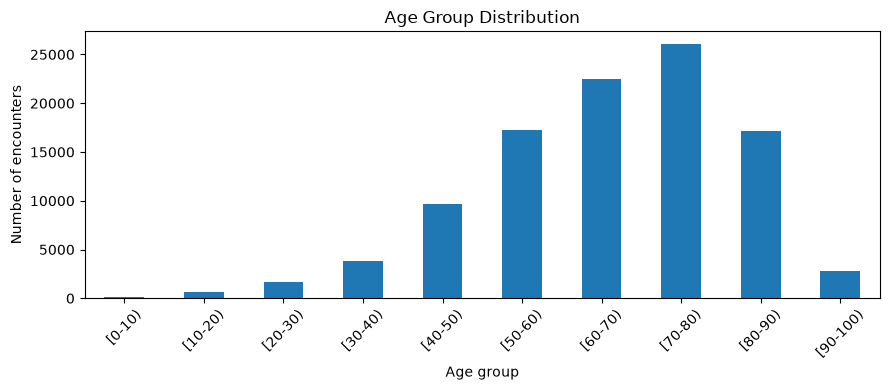

In [13]:
# Cell 13: EDA visualization — age distribution

plt.figure(figsize=(9, 4))
df["age"].value_counts().sort_index().plot(kind="bar")
plt.title("Age Group Distribution")
plt.xlabel("Age group")
plt.ylabel("Number of encounters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

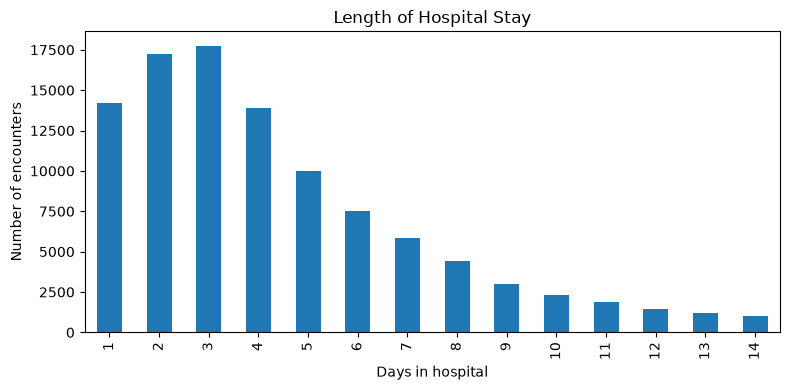

In [14]:
# Cell 14: EDA visualization — length of hospital stay

plt.figure(figsize=(8, 4))
df["time_in_hospital"].value_counts().sort_index().plot(kind="bar")
plt.title("Length of Hospital Stay")
plt.xlabel("Days in hospital")
plt.ylabel("Number of encounters")
plt.tight_layout()
plt.show()

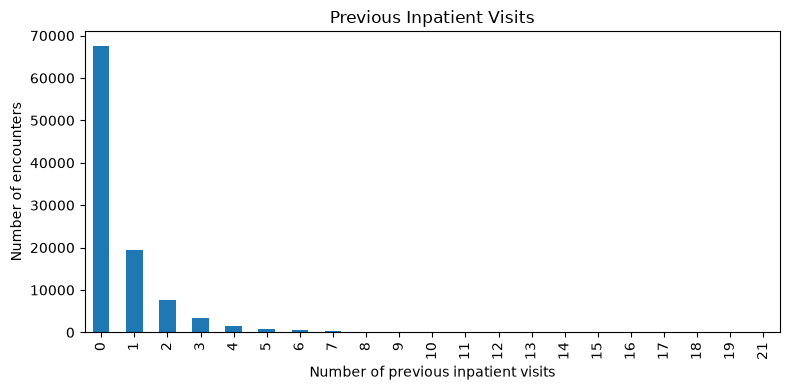

In [15]:
# Cell 15: EDA visualization — previous inpatient visits

plt.figure(figsize=(8, 4))
df["number_inpatient"].value_counts().sort_index().head(30).plot(kind="bar")
plt.title("Previous Inpatient Visits")
plt.xlabel("Number of previous inpatient visits")
plt.ylabel("Number of encounters")
plt.tight_layout()
plt.show()

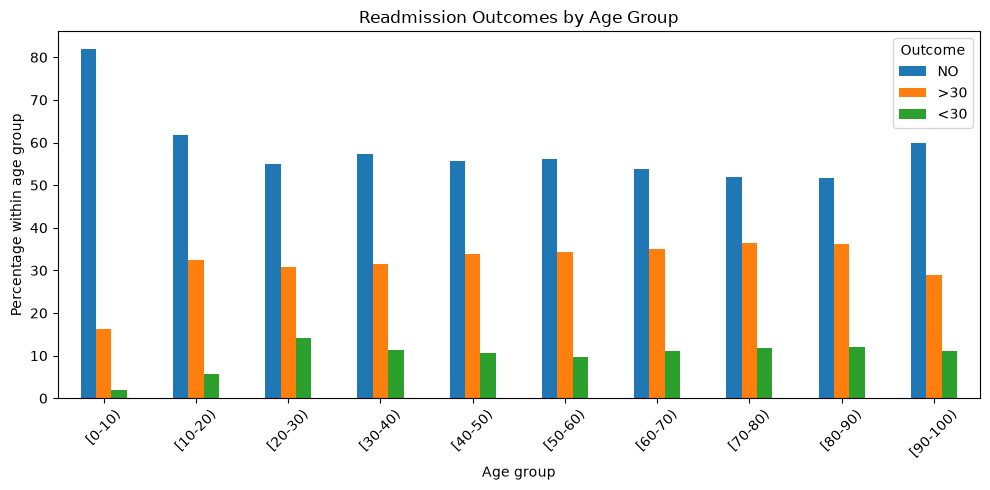

In [16]:
# Cell 16: EDA visualization — target by age group

age_target_table = pd.crosstab(
    df["age"],
    df["readmitted"],
    normalize="index"
).reindex(columns=["NO", ">30", "<30"]) * 100

age_target_table.plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Readmission Outcomes by Age Group")
plt.xlabel("Age group")
plt.ylabel("Percentage within age group")
plt.xticks(rotation=45)
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

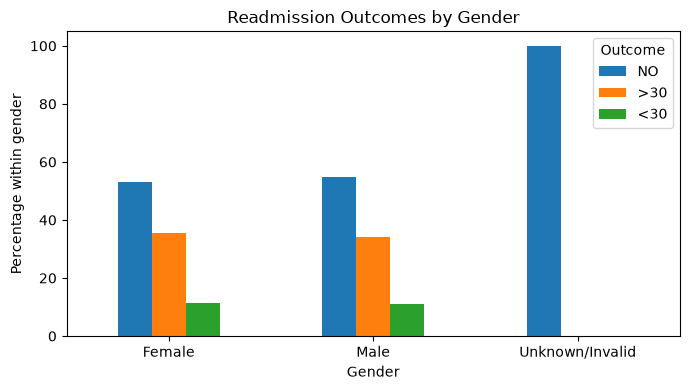

In [17]:
# Cell 17: EDA visualization — target by gender

gender_target_table = pd.crosstab(
    df["gender"],
    df["readmitted"],
    normalize="index"
).reindex(columns=["NO", ">30", "<30"]) * 100

gender_target_table.plot(
    kind="bar",
    figsize=(7, 4)
)
plt.title("Readmission Outcomes by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage within gender")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

In [18]:
# Cell 18: Create a separate working copy for preprocessing

df_work = df.copy()

# Preserve the original target as three classes.
# Do not combine the categories.
print(df_work["readmitted"].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64
